In [102]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential 
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

tf.random.set_seed(1234)

In [103]:
X = np.load('./dataset/handsignX.npy')
y = np.load('./dataset/handsigny.npy')

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")




X_train, X_cv, y_train, y_cv = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_cv: {X_cv.shape}")
print(f"Shape of y_test: {y_cv.shape}")

print(X_cv)

m,n = X.shape


# np.imshow(X)

Shape of X: (5000, 400)
Shape of y: (5000, 1)
Shape of X_train: (4000, 400)
Shape of y_train: (4000, 1)
Shape of X_cv: (1000, 400)
Shape of y_test: (1000, 1)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


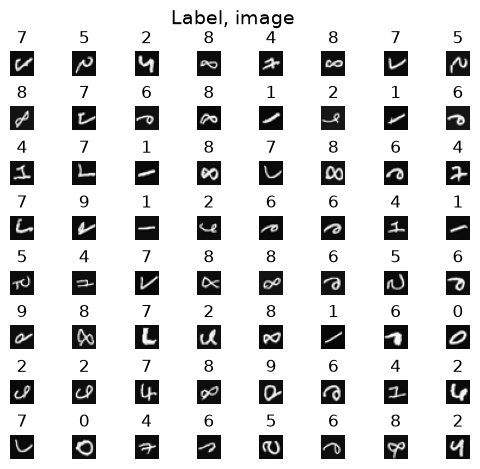

In [104]:
fig,axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91])

for i,ax in enumerate(axes.flat):
    rand_idx = np.random.randint(m)
    X_reshaped = X[rand_idx].reshape(20,20)
    ax.imshow(X_reshaped, cmap='grey')
    ax.set_title(y[rand_idx,0])
    ax.set_axis_off()
    fig.suptitle("Label, image", fontsize=14)



In [105]:


def nn_model(X_train, y_train, X_cv, y_cv, l_rate, regularizer, epoch):

    model = Sequential([
        Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(regularizer)),
        Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(regularizer)),
        Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(regularizer))
    ])

    # model.summary()
    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer = tf.keras.optimizers.Adam(l_rate),
        metrics=['accuracy']
    )

    model.fit(X_train,y_train, epochs=epoch)
    print('\n')

    train_loss, train_acc = model.evaluate(X_train, y_train)
    cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
    print(f"Train Accuracy: {train_acc*100:.2f}")
    print(f"CV Accuracy: {cv_acc*100:.2f}")


In [106]:

regularizer = [0.01, 0.001,0.0001,0.0005]


model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.01)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.01)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.01))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.01),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7830 - loss: 1.5363  
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8485 - loss: 1.0941  
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step - accuracy: 0.8537 - loss: 1.0529
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - accuracy: 0.8595 - loss: 1.0345
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step - accuracy: 0.8627 - loss: 1.0168
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8635 - loss: 1.0155  
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step - accuracy: 0.8610 - loss: 1.0120
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step - accuracy: 0.8648 - loss: 1.0000
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - accuracy: 0.8673 - loss: 0.9915
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step - accuracy: 0.8695 - loss: 0.9792
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step - accuracy: 0.8715 - loss: 0.9708
Epoch 12/15
125/125 ━━━━━━━━━━

In [107]:
model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.001)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.001)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.001))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.002),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 977us/step - accuracy: 0.7987 - loss: 0.9487
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 943us/step - accuracy: 0.9168 - loss: 0.4841
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step - accuracy: 0.9430 - loss: 0.4036
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 977us/step - accuracy: 0.9560 - loss: 0.3612
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - accuracy: 0.9655 - loss: 0.3310
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - accuracy: 0.9715 - loss: 0.3084
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step - accuracy: 0.9765 - loss: 0.2910
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - accuracy: 0.9810 - loss: 0.2768
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 943us/step - accuracy: 0.9845 - loss: 0.2650
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - accuracy: 0.9872 - loss: 0.2552
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - accuracy: 0.9870 - loss: 0.2479
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 

In [108]:


model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.0001)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.0001)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.0001))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.01),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 976us/step - accuracy: 0.8350 - loss: 0.5905
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9222 - loss: 0.3126  
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - accuracy: 0.9390 - loss: 0.2612
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - accuracy: 0.9470 - loss: 0.2503
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - accuracy: 0.9657 - loss: 0.2027
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9605 - loss: 0.2182  
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9690 - loss: 0.2166  
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - accuracy: 0.9682 - loss: 0.2141
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - accuracy: 0.9685 - loss: 0.2197
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - accuracy: 0.9665 - loss: 0.2389
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - accuracy: 0.9697 - loss: 0.2171
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 

In [109]:
model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.0005)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.0005)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.0005))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.001),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 986us/step - accuracy: 0.7455 - loss: 1.0694
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step - accuracy: 0.9125 - loss: 0.4564
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step - accuracy: 0.9340 - loss: 0.3675
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - accuracy: 0.9460 - loss: 0.3200
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - accuracy: 0.9567 - loss: 0.2871
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9665 - loss: 0.2616  
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9735 - loss: 0.2413  
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - accuracy: 0.9787 - loss: 0.2253
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - accuracy: 0.9825 - loss: 0.2121
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - accuracy: 0.9860 - loss: 0.2013
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step - accuracy: 0.9887 - loss: 0.1925
Epoch 12/15
125/125 ━━━━━━━━━━

### Below I have provided and retrained the finalized model
*  Train Accuracy: 98.25%

*  CV Accuracy: 92.60%

*  The Gap: Just 5.65%

In [110]:
model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.001)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.001)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.001))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.002),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")


Epoch 1/15


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8095 - loss: 0.9218  
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - accuracy: 0.9205 - loss: 0.4869
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9435 - loss: 0.4093  
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9582 - loss: 0.3642  
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9657 - loss: 0.3350  
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9707 - loss: 0.3112  
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9768 - loss: 0.2910  
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - accuracy: 0.9812 - loss: 0.2744
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9847 - loss: 0.2631  
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9875 - loss: 0.2520  
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9900 - loss: 0.2427  
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 

In [111]:
X_test = np.load('./dataset/testdata/captured_2/dataset_2.npy')
y_test = np.load('./dataset/testdata/captured_2/labels_2.npy')
# X_test = np.load('./dataset/testdata/dataset.npy')
# y_test = np.load('./dataset/testdata/labels.npy')

# X_test = X_test[:, :2]
m = X_test.shape[0]

print(X_test.shape)
print(y_test.shape)


print(X_test)

(104, 28, 28)
(104,)
[[[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 [[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 [[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 ...

 [[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 [[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0 

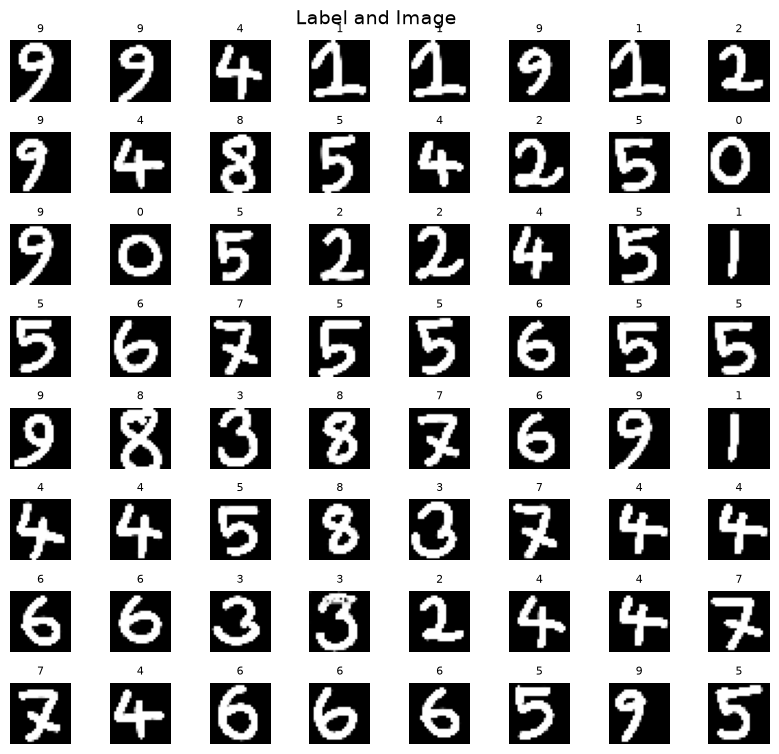

In [112]:
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.13, rect=[0, 0.03, 1, 0.95])

for ax in axes.flat:
    rand_idx = np.random.randint(len(X_test))

    ax.imshow(X_test[rand_idx], cmap='gray')
    ax.set_title(str(y_test[rand_idx]), fontsize=8)
    ax.axis('off')

fig.suptitle("Label and Image", fontsize=14)
plt.show()

In [113]:
from skimage.transform import resize

# X_test has shape (104, 64, 64)

X_test_resized = np.array([
    resize(img, (20, 20), anti_aliasing=True, preserve_range=True)
    for img in X_test
])


X_test_resized = X_test_resized.astype(np.float64)

if X_test_resized.max() > 1:
    X_test_resized /= 255.0

print(X_test_resized.shape)

(104, 20, 20)


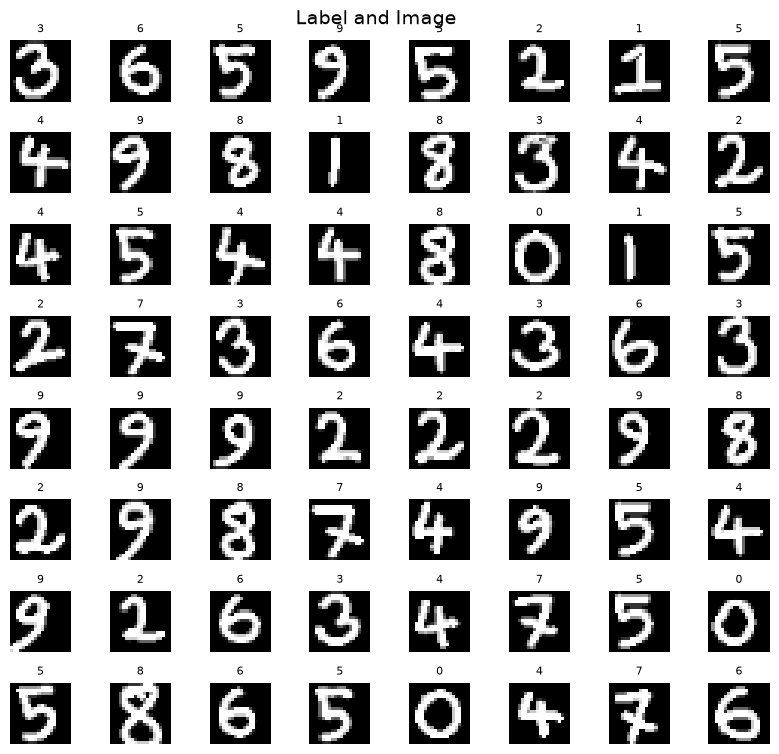

In [114]:
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.13, rect=[0, 0.03, 1, 0.95])

for ax in axes.flat:
    rand_idx = np.random.randint(len(X_test))

    ax.imshow(X_test_resized[rand_idx], cmap='gray')
    ax.set_title(str(y_test[rand_idx]), fontsize=8)
    ax.axis('off')

fig.suptitle("Label and Image", fontsize=14)
plt.show()

In [115]:
X_test_resized = X_test_resized.reshape(-1, 400)
logits = model.predict(X_test_resized)
predictions = np.argmax(logits, axis=1)

print(predictions)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
[6 2 0 0 6 2 0 0 4 4 7 7 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 6 6 6 6 6 6 6 6 6
 2 6 3 3 2 3 1 1 1 9 3 3 3 6 3 3 3 3 6 2 3 4 4 3 4 4 3 3 3 4 5 8 8 3 8 8 3
 0 2 7 2 2 2 2 7 7 7 6 6 8 6 2 4 8 8 4 4 4 6 7 4 4 4 4 4 4 4]


In [116]:
train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
test_loss, test_acc = model.evaluate(X_test_resized, y_test)

print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")
print(f"Test Accuracy: {test_acc*100:.2f}")



  1/125 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9688 - loss: 0.2481

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step - accuracy: 0.9762 - loss: 0.2521
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9200 - loss: 0.4403 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1058 - loss: 8.3011 
Train Accuracy: 97.62
CV Accuracy: 92.00
Test Accuracy: 10.58


In [117]:
print(X_train.min(), X_train.max())
print(X_test_resized.min(), X_test_resized.max())

logits = model.predict(X_test_resized)
pred = np.argmax(logits, axis=1)

print(np.unique(pred, return_counts=True))
print(pred[:20])
print(y_test[:20])

-0.11993388483543918 1.127688299158888
0.0 1.0
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([ 5,  3, 11, 17, 33,  2, 18,  7,  7,  1]))
[6 2 0 0 6 2 0 0 4 4 7 7 4 4 4 4 5 4 4 4]
[0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 2 2 2]


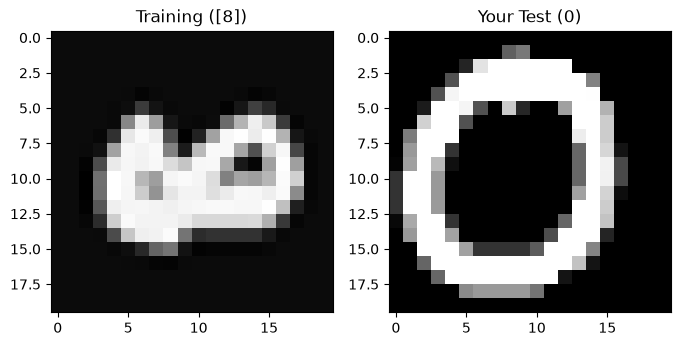

In [118]:
plt.figure(figsize=(8,4))

plt.subplot(121)
plt.imshow(X_train[0].reshape(20,20), cmap='gray')
plt.title(f"Training ({y_train[0]})")

plt.subplot(122)
plt.imshow(X_test_resized[0].reshape(20,20), cmap='gray')
plt.title(f"Your Test ({y_test[0]})")

plt.show()

In [119]:
from skimage.transform import resize
from scipy import ndimage

def preprocess_like_training(images, out_size=20, digit_box=14, threshold=0.35):
    """Crop to bounding box, rescale to fit inside `digit_box`, center by
    center of mass, and pad back out to (out_size, out_size). This mimics
    the padding/margin/centering already present in the training glyphs."""
    processed = []
    for img in images:
        img = img.astype(np.float64)
        if img.max() > 0:
            img = img / img.max()

        mask = img > threshold
        if mask.sum() == 0:
            processed.append(np.zeros((out_size, out_size), dtype=np.float32))
            continue

        rows = np.any(mask, axis=1)
        cols = np.any(mask, axis=0)
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]

        cropped = img[rmin:rmax + 1, cmin:cmax + 1]

        h, w = cropped.shape
        scale = digit_box / max(h, w)
        new_h = max(1, int(round(h * scale)))
        new_w = max(1, int(round(w * scale)))
        resized_digit = resize(cropped, (new_h, new_w), preserve_range=True, anti_aliasing=True)

        canvas = np.zeros((out_size, out_size))
        top = (out_size - new_h) // 2
        left = (out_size - new_w) // 2
        canvas[top:top + new_h, left:left + new_w] = resized_digit

        cy, cx = ndimage.center_of_mass(canvas)
        if not (np.isnan(cy) or np.isnan(cx)):
            shift_y, shift_x = out_size / 2 - cy, out_size / 2 - cx
            canvas = ndimage.shift(canvas, shift=(shift_y, shift_x), mode='constant', cval=0)

        processed.append(canvas.astype(np.float32))

    return np.array(processed)

X_test_aligned = preprocess_like_training(X_test)
X_test_aligned_flat = X_test_aligned.reshape(-1, 400)

print("train range:", X_train.min(), X_train.max())
print("aligned test range:", X_test_aligned_flat.min(), X_test_aligned_flat.max())

train range: -0.11993388483543918 1.127688299158888
aligned test range: -0.21208759 1.3055383


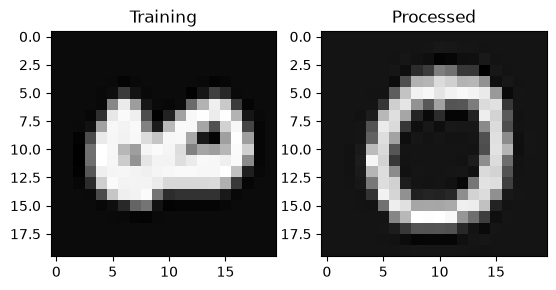

In [120]:
plt.subplot(121)
plt.imshow(X_train[0].reshape(20,20), cmap='gray')
plt.title("Training")

plt.subplot(122)
plt.imshow(X_test_aligned_flat[0].reshape(20,20), cmap='gray')
plt.title("Processed")

plt.show()

In [121]:
train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
test_loss, test_acc = model.evaluate(X_test_aligned_flat, y_test)

print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")
print(f"Test Accuracy: {test_acc*100:.2f}")


  1/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9688 - loss: 0.2481

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step - accuracy: 0.9762 - loss: 0.2521
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9200 - loss: 0.4403 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1731 - loss: 8.6695 
Train Accuracy: 97.62
CV Accuracy: 92.00
Test Accuracy: 17.31


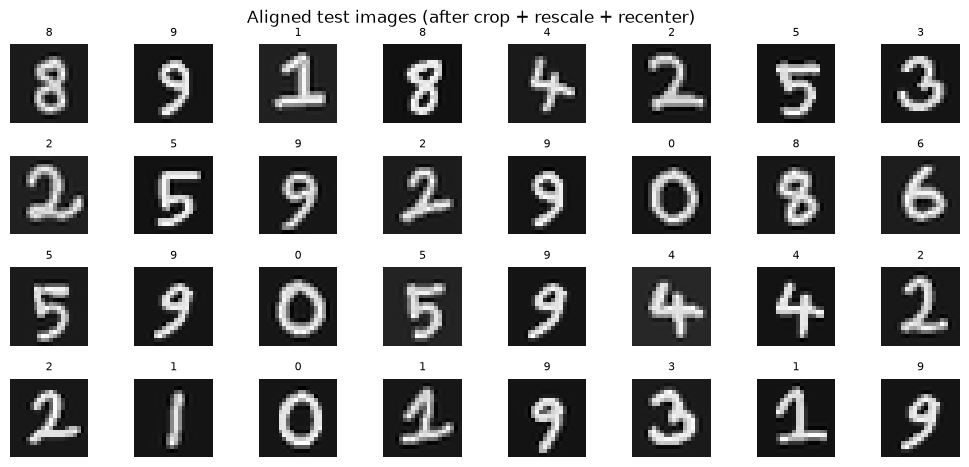

In [122]:
fig, axes = plt.subplots(4, 8, figsize=(10, 5))
fig.tight_layout(pad=0.3, rect=[0, 0.03, 1, 0.93])

for ax in axes.flat:
    rand_idx = np.random.randint(len(X_test_aligned))
    ax.imshow(X_test_aligned[rand_idx], cmap='gray')
    ax.set_title(str(y_test[rand_idx]), fontsize=8)
    ax.axis('off')

fig.suptitle("Aligned test images (after crop + rescale + recenter)", fontsize=12)
plt.show()

In [123]:
train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
test_loss, test_acc = model.evaluate(X_test_aligned_flat, y_test)

print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")
print(f"Test Accuracy (aligned): {test_acc*100:.2f}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step - accuracy: 0.9762 - loss: 0.2521
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9200 - loss: 0.4403 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1731 - loss: 8.6695 
Train Accuracy: 97.62
CV Accuracy: 92.00
Test Accuracy (aligned): 17.31


In [124]:
print("TRAIN  mean pixel value:", X_train.mean(), " | fraction of 'bright' (>0.5) pixels:", (X_train > 0.5).mean())
print("ALIGNED TEST mean pixel value:", X_test_aligned_flat.mean(), " | fraction of 'bright' (>0.5) pixels:", (X_test_aligned_flat > 0.5).mean())

TRAIN  mean pixel value: 0.13169781631835226  | fraction of 'bright' (>0.5) pixels: 0.1323875
ALIGNED TEST mean pixel value: 0.16723882  | fraction of 'bright' (>0.5) pixels: 0.16608173076923077


In [125]:
train_fg_ratio = (X_train > 0.5).mean()
test_fg_ratio = (X_test_aligned_flat > 0.5).mean()

if abs(train_fg_ratio - test_fg_ratio) > 0.15 and abs((1 - test_fg_ratio) - train_fg_ratio) < abs(test_fg_ratio - train_fg_ratio):
    print("Polarity mismatch detected -> inverting aligned test images")
    X_test_aligned_flat = 1.0 - X_test_aligned_flat
    X_test_aligned = 1.0 - X_test_aligned
else:
    print("No strong polarity mismatch detected; leaving images as-is")

print("Corrected test fg ratio:", (X_test_aligned_flat > 0.5).mean())


No strong polarity mismatch detected; leaving images as-is
Corrected test fg ratio: 0.16608173076923077


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Prediction counts: (array([0, 2, 4, 6, 7, 8]), array([ 9,  2, 34, 55,  1,  3]))
True label counts: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([ 9,  8, 11, 11, 13, 15,  8,  9,  8, 12]))


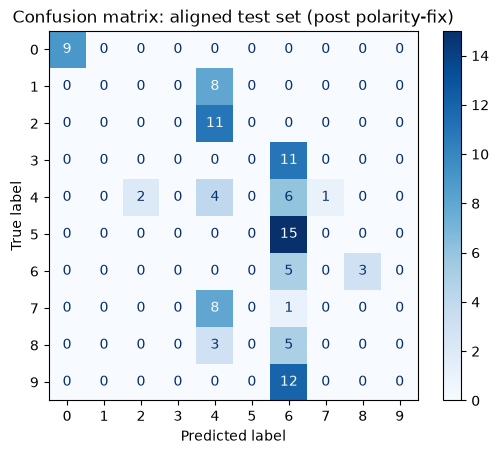

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1731 - loss: 8.6695 
Test Accuracy (aligned + polarity-checked): 17.31


In [126]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

logits = model.predict(X_test_aligned_flat)
pred = np.argmax(logits, axis=1)

print("Prediction counts:", np.unique(pred, return_counts=True))
print("True label counts:", np.unique(y_test, return_counts=True))

cm = confusion_matrix(y_test, pred, labels=list(range(10)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion matrix: aligned test set (post polarity-fix)")
plt.show()

test_loss, test_acc = model.evaluate(X_test_aligned_flat, y_test)
print(f"Test Accuracy (aligned + polarity-checked): {test_acc*100:.2f}")
